<a href="https://colab.research.google.com/github/imdann06/estructra_de_bases_de_datos/blob/main/KD_Tree/KDtree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problema

Eres parte de un equipo que desarrolla un sistema de logistica en una ciudad. Tienes coordenadas (x,y) de 10.000 puntos de entrega. Necesitas implementar un sistema que responda eficientemente preguntas como:

* ¿Que puntos de entrega estan a un radio de 500 metros de un punto dado?( tener en cuenta unidades)
* ¿cual es el punto de entrega mas cercano a una ubicacion dada?

Objetivo Implementar un arbol-KD desde cero, comparar con fuerza bruta.


Micro tareas para resolver el ejercico:
+ construir el arbol KD ( no se pueden usar arboles ya generados o librerias como scipy)
+ Implementar busqueda dentro de un radio (range search)
+ Vecinos ( puntos encontrados dentro del radio) y encontrar los mas cercanos
+ Verificacion visual de radio y puntos encontrados dentro del radio.
+ Verificacion visual de los vecinos mas cercanos.

Notas:
+ Importantetrate de hacer el codigo para k dimensiones, sino puede ser solo para 2D
+ No se permiten soluciones completas de internet o vibecoding se pueden apoyar de ia o internet
+ se puede hacer preguntas

Responder las siguientes preguntas con el analisis comparativos:

+ para que tamaño de datos el arbol- KD comieza a ser mas rapido que "fuerza bruta" (no arboles, si listas, ...)?


In [2]:
import math
import random
import time

# Clase para representar un nodo en el árbol KD
class Nodo:
    def __init__(self, punto, eje, izquierda=None, derecha=None):
        self.punto = punto  # Coordenadas del punto en el nodo (ej. (x, y))
        self.eje = eje      # Eje de división utilizado en este nodo (0 para x, 1 para y)
        self.izquierda = izquierda  # Subárbol izquierdo
        self.derecha = derecha    # Subárbol derecho

# Clase para el árbol KD
class ArbolKD:
    def __init__(self, puntos):
        # Construye el árbol KD a partir de una lista de puntos
        self.raiz = self.construir(puntos, profundidad=0)

    def construir(self, puntos, profundidad):
        # Función recursiva para construir el árbol KD
        if not puntos:
            return None

        # Determina el eje de división actual (alterna entre x e y)
        eje = profundidad % 2  # 0 = x, 1 = y

        # Organizamos los datos según el eje actual para encontrar la mediana
        puntos_ordenados = sorted(puntos, key=lambda p: p[eje])
        """
        Considerando que la distribucion es homogenea
        """
        # Elige el punto mediano como el nodo actual
        mediana = len(puntos_ordenados) // 2

        # Crea un nuevo nodo y construye recursivamente los subárboles izquierdo y derecho
        return Nodo(
            punto=puntos_ordenados[mediana],
            eje=eje,
            izquierda=self.construir(puntos_ordenados[:mediana], profundidad + 1),
            derecha=self.construir(puntos_ordenados[mediana + 1:], profundidad + 1)
        )

    def distancia(self, p1, p2):
        # Calcula la distancia entre dos punros
        return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

    def buscar_en_radio(self, nodo, punto_consulta, radio, resultados):
        # Función recursiva para buscar puntos dentro de un radio dado
        if nodo is None:
            return

        # Revisa si el punto del nodo actual está dentro del radio de la consulta
        if self.distancia(nodo.punto, punto_consulta) <= radio:
            resultados.append(nodo.punto)

        eje = nodo.eje

        # Calcula la diferencia entre la coordenada del punto de consulta y el plano de división del nodo
        diferencia = punto_consulta[eje] - nodo.punto[eje]

        # Determina qué lado del subárbol explorar primero (el más cercano al punto de consulta)
        if diferencia <= 0:
            lado_cercano = nodo.izquierda
            lado_lejano = nodo.derecha
        else:
            lado_cercano = nodo.derecha
            lado_lejano = nodo.izquierda

        # Explora el lado cercano del subárbol
        self.buscar_en_radio(lado_cercano, punto_consulta, radio, resultados)

        # Explora el lado lejano solo si el radio de búsqueda cruza el plano de división
        if abs(diferencia) <= radio:
            self.buscar_en_radio(lado_lejano, punto_consulta, radio, resultados)

    def busqueda_vecinos(self, punto_consulta, radio):
        # Inicia la búsqueda en el árbol KD para encontrar puntos dentro de un radio
        resultados = []
        self.buscar_en_radio(self.raiz, punto_consulta, radio, resultados)
        return resultados

# ----------------------------
# FUERZA BRUTA
# ----------------------------

def fuerza_bruta_radio(puntos, punto_consulta, radio):
    # Implementación de búsqueda por fuerza bruta: itera sobre todos los puntos
    resultados = []

    for p in puntos:
        # Calcula el cuadrado de la distancia para evitar la raíz cuadrada en cada iteración
        distancia2 = (p[0] - punto_consulta[0])**2 + (p[1] - punto_consulta[1])**2

        # Si la distancia es menor o igual al radio, añade el punto a los resultados
        if distancia2 <= radio**2:
            resultados.append(p)

    return resultados


# GENERAR 10.000 PUNTOS


LADO = 10000  # Define el tamaño del lado de la cuadrícula en metros (10 km)

# Genera 10.000 puntos aleatorios dentro de un cuadrado de LADO x LADO
puntos = [
    (random.randint(0, LADO), random.randint(0, LADO))
    for _ in range(10000)
]

# ----------------------------
# CONSTRUIR EL ÁRBOL KD
# ----------------------------

arbol = ArbolKD(puntos)

# ----------------------------
# HACER UNA CONSULTA DE EJEMPLO
# ----------------------------

# Genera un punto de consulta aleatorio
punto_consulta = (
    random.randint(0, LADO),
    random.randint(0, LADO)
)

print("Punto de consulta:", punto_consulta)
radio = 500 #radio

# Realiza la búsqueda en el árbol KD
resultado = arbol.busqueda_vecinos(punto_consulta, radio)

# Encuentra el vecino más cercano dentro de los resultados obtenidos (si hay alguno)
if resultado:
    mas_cercano = min(
        resultado,
        key=lambda p: (p[0] - punto_consulta[0])**2 + (p[1] - punto_consulta[1])**2
    )
    print("Vecino más cercano dentro del radio:", mas_cercano)

print("Cantidad de puntos dentro de 500 metros:", len(resultado))
# Imprime los puntos encontrados dentro del radio
for punto in resultado:
    print(punto)


Punto de consulta: (1274, 4168)
Vecino más cercano dentro del radio: (1261, 4165)
Cantidad de puntos dentro de 500 metros: 74
(1576, 3955)
(1489, 4120)
(1381, 4167)
(1353, 4186)
(1327, 4135)
(1261, 4165)
(1363, 4189)
(1439, 4293)
(1523, 4220)
(1469, 4251)
(1532, 4332)
(1403, 3697)
(1395, 4078)
(1345, 4110)
(1307, 4015)
(1297, 3859)
(1482, 3991)
(1452, 4054)
(1493, 3785)
(1425, 3809)
(1735, 4354)
(1624, 4253)
(1656, 4128)
(1617, 4099)
(1715, 4267)
(1720, 3983)
(1689, 4018)
(1263, 4649)
(1366, 4634)
(1325, 4615)
(1331, 4570)
(1315, 4484)
(1255, 4617)
(1505, 4414)
(1498, 4591)
(1373, 4636)
(1593, 4431)
(1584, 4508)
(1067, 3848)
(1120, 4315)
(894, 4311)
(1075, 4116)
(1088, 4302)
(1225, 4282)
(1146, 4259)
(1178, 4291)
(968, 4245)
(1001, 4213)
(895, 4185)
(1014, 4288)
(1062, 4031)
(1242, 3937)
(1132, 3998)
(1124, 3849)
(1074, 3924)
(911, 4087)
(957, 4109)
(976, 3880)
(968, 3962)
(809, 4225)
(849, 4130)
(837, 4009)
(1098, 4321)
(1174, 4421)
(1168, 4545)
(999, 4471)
(1060, 4452)
(965, 4375)
(8

In [3]:
# ----------------------------
# MEDIR TIEMPOS PROMEDIO
# ----------------------------
NUM_PRUEBAS = 1000

tiempo_total_kd = 0
tiempo_total_fb = 0

for i in range(NUM_PRUEBAS):

    # KD-Tree
    inicio = time.time()
    arbol.busqueda_vecinos(punto_consulta, radio)
    tiempo_total_kd += time.time() - inicio

    # Fuerza bruta
    inicio = time.time()
    fuerza_bruta_radio(puntos, punto_consulta, radio)
    tiempo_total_fb += time.time() - inicio


# calcular promedios
promedio_kd = tiempo_total_kd / NUM_PRUEBAS
promedio_fb = tiempo_total_fb / NUM_PRUEBAS

print("TIEMPOS PROMEDIO")
print(f"KD-Tree: {promedio_kd:.6f} segundos")
print(f"Fuerza bruta: {promedio_fb:.6f} segundos")

TIEMPOS PROMEDIO
KD-Tree: 0.000170 segundos
Fuerza bruta: 0.004099 segundos


In [7]:
# ============================
# EXPERIMENTOS COMPARATIVOS
# ============================

def experimento_comparativo(tamanos, num_consultas=20, lado=20000, radio=500):
    # Imprime el encabezado para el experimento
    print("\n==============================")
    print("EXPERIMENTO KD-TREE VS FUERZA BRUTA")
    print("==============================")

    for n in tamanos:
        # Genera "n" puntos aleatorios para el conjunto de datos actual
        puntos = [
            (random.randint(0, lado), random.randint(0, lado))
            for i in range(n)
        ]

        # Medir tiempo de construcción del árbol KD
        inicio_construccion = time.time()
        arbol = ArbolKD(puntos)
        tiempo_construccion = time.time() - inicio_construccion

        tiempo_total_kd = 0
        tiempo_total_fb = 0
        coincidencias = True # Bandera para verificar si los resultados coinciden

        # Realiza múltiples consultas para obtener un tiempo promedio
        for i in range(num_consultas):
            # Genera un punto de consulta aleatorio para cada iteración
            punto_consulta = (
                random.randint(0, lado),
                random.randint(0, lado)
            )

            # Mide el tiempo de búsqueda con KD-Tree
            inicio_kd = time.time()
            resultado_kd = arbol.busqueda_vecinos(punto_consulta, radio)
            tiempo_total_kd += time.time() - inicio_kd

            # Mide el tiempo de búsqueda con Fuerza Bruta
            inicio_fb = time.time()
            resultado_fb = fuerza_bruta_radio(puntos, punto_consulta, radio)
            tiempo_total_fb += time.time() - inicio_fb
            # Verifica si los resultados de ambos métodos son idénticos (conjuntos)
            if set(resultado_kd) != set(resultado_fb):
                coincidencias = False

        # Calcula el tiempo promedio de consulta para cada método
        promedio_kd = tiempo_total_kd / num_consultas
        promedio_fb = tiempo_total_fb / num_consultas

        # Imprime los resultados para el tamaño de datos actual
        print(f"\nTamaño de datos: {n}")
        print (f"Tiempo construcción KD-Tree: {tiempo_construccion:.6f} s")
        print(f"Tiempo promedio consulta KD-Tree: {promedio_kd:.6f} s")
        print(f"Tiempo promedio fuerza bruta: {promedio_fb:.6f} s")
        print(f"¿Resultados iguales en todas las consultas?: {coincidencias}")

        # Compara y muestra qué método fue más rápido
        if promedio_kd < promedio_fb:
            print("KD-Tree fue más rápido en promedio")
        elif promedio_fb < promedio_kd:
            print("Fuerza bruta fue más rápida en promedio")
        else:
            print("Empate")

In [11]:
# Define una lista de tamaños de datos para probar en el experimento
tamanos_prueba = [7, 8,9, 10 ,20 ,50, 100, 500, 1000, 2000, 5000, 10000]
# Ejecuta el experimento comparativo con los tamaños definidos
experimento_comparativo(tamanos_prueba, num_consultas=20, lado=10000, radio=500)


EXPERIMENTO KD-TREE VS FUERZA BRUTA

Tamaño de datos: 7
Tiempo construcción KD-Tree: 0.000023 s
Tiempo promedio consulta KD-Tree: 0.000003 s
Tiempo promedio fuerza bruta: 0.000002 s
¿Resultados iguales en todas las consultas?: True
Fuerza bruta fue más rápida en promedio

Tamaño de datos: 8
Tiempo construcción KD-Tree: 0.000017 s
Tiempo promedio consulta KD-Tree: 0.000003 s
Tiempo promedio fuerza bruta: 0.000002 s
¿Resultados iguales en todas las consultas?: True
Fuerza bruta fue más rápida en promedio

Tamaño de datos: 9
Tiempo construcción KD-Tree: 0.000016 s
Tiempo promedio consulta KD-Tree: 0.000003 s
Tiempo promedio fuerza bruta: 0.000003 s
¿Resultados iguales en todas las consultas?: True
KD-Tree fue más rápido en promedio

Tamaño de datos: 10
Tiempo construcción KD-Tree: 0.000018 s
Tiempo promedio consulta KD-Tree: 0.000002 s
Tiempo promedio fuerza bruta: 0.000005 s
¿Resultados iguales en todas las consultas?: True
KD-Tree fue más rápido en promedio

Tamaño de datos: 20
Tiempo 

In [14]:
# ============================
# EXPERIMENTOS COMPARATIVOS
# ============================

def experimento_comparativo(tamanos, num_consultas=20, lado=20000, radio=500):
    # Imprime el encabezado para el experimento
    print("\n==============================")
    print("EXPERIMENTO KD-TREE VS FUERZA BRUTA")
    print("==============================")

    tabla = []

    for n in tamanos:
        # Genera "n" puntos aleatorios para el conjunto de datos actual
        puntos = [
            (random.randint(0, lado), random.randint(0, lado))
            for i in range(n)
        ]

        # Medir tiempo de construcción del árbol KD
        inicio_construccion = time.time()
        arbol = ArbolKD(puntos)
        tiempo_construccion = time.time() - inicio_construccion

        tiempo_total_kd = 0
        tiempo_total_fb = 0
        coincidencias = True # Bandera para verificar si los resultados coinciden

        # Realiza múltiples consultas para obtener un tiempo promedio
        for i in range(num_consultas):
            # Genera un punto de consulta aleatorio para cada iteración
            punto_consulta = (
                random.randint(0, lado),
                random.randint(0, lado)
            )

            # Mide el tiempo de búsqueda con KD-Tree
            inicio_kd = time.time()
            resultado_kd = arbol.busquedaVecinos(punto_consulta, radio)
            tiempo_total_kd += time.time() - inicio_kd

            # Mide el tiempo de búsqueda con Fuerza Bruta
            inicio_fb = time.time()
            resultado_fb = fuerza_bruta_radio(puntos, punto_consulta, radio)
            tiempo_total_fb += time.time() - inicio_fb

            # Verifica si los resultados de ambos métodos son idénticos (conjuntos)
            if set(resultado_kd) != set(resultado_fb):
                coincidencias = False

        # Calcula el tiempo promedio de consulta para cada método
        promedio_kd = tiempo_total_kd / num_consultas
        promedio_fb = tiempo_total_fb / num_consultas

        tabla.append({
            "n": n,
            "tiempo_construccion": tiempo_construccion,
            "promedio_kd": promedio_kd,
            "promedio_fb": promedio_fb,
            "coincidencias": coincidencias
        })

        # Imprime los resultados para el tamaño de datos actual
        print(f"\nTamaño de datos: {n}")
        print (f"Tiempo construcción KD-Tree: {tiempo_construccion:.6f} s")
        print(f"Tiempo promedio consulta KD-Tree: {promedio_kd:.6f} s")
        print(f"Tiempo promedio fuerza bruta: {promedio_fb:.6f} s")
        print(f"¿Resultados iguales en todas las consultas?: {coincidencias}")

        # Compara y muestra qué método fue más rápido
        if promedio_kd < promedio_fb:
            print("KD-Tree fue más rápido en promedio")
        elif promedio_fb < promedio_kd:
            print("Fuerza bruta fue más rápida en promedio")
        else:
            print("Empate")

    return tabla



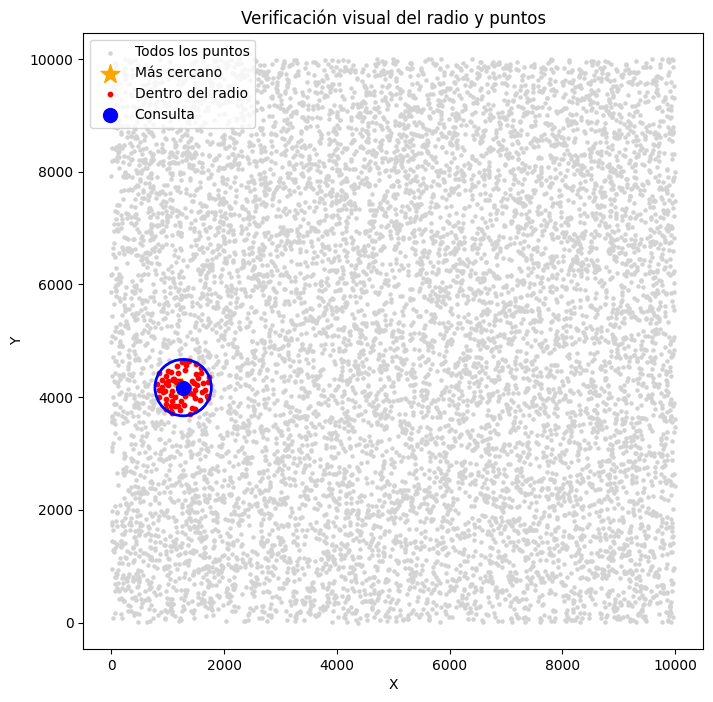

In [15]:
import matplotlib.pyplot as plt

# ----------------------------
# VISUALIZACIÓN DE TODOS LOS PUNTOS Y EL RADIO DE CONSULTA
# ----------------------------

# Separa las coordenadas X e Y de todos los puntos para la visualización
x_all = [p[0] for p in puntos]
y_all = [p[1] for p in puntos]

# Separa las coordenadas X e Y de los puntos encontrados dentro del radio
x_vecinos = [p[0] for p in resultado]
y_vecinos = [p[1] for p in resultado]

# Crea una nueva figura para el gráfico
plt.figure(figsize=(8, 8))

# Dibuja todos los puntos generados en gris claro
plt.scatter(x_all, y_all, s=5, color='lightgray', label="Todos los puntos")

# Si hay resultados, dibuja el punto más cercano dentro del radio con una estrella naranja
if resultado:
    plt.scatter(mas_cercano[0], mas_cercano[1],
                color='orange', s=200, marker='*', label="Más cercano")


# Dibuja los puntos encontrados dentro del radio en rojo
plt.scatter(x_vecinos, y_vecinos, s=10, color='red', label="Dentro del radio")

# Dibuja el punto de consulta en azul
plt.scatter(punto_consulta[0], punto_consulta[1], color='blue', s=100, label="Consulta")

# Dibuja el círculo que representa el radio de búsqueda
circulo = plt.Circle(punto_consulta, radio, color='blue', fill=False, linewidth=2)
plt.gca().add_patch(circulo)

# Configura los detalles del gráfico
plt.title("Verificación visual del radio y puntos")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend() # Muestra la leyenda
plt.axis('equal') # Asegura que los ejes tengan la misma escala

plt.show() # Muestra el gráfico

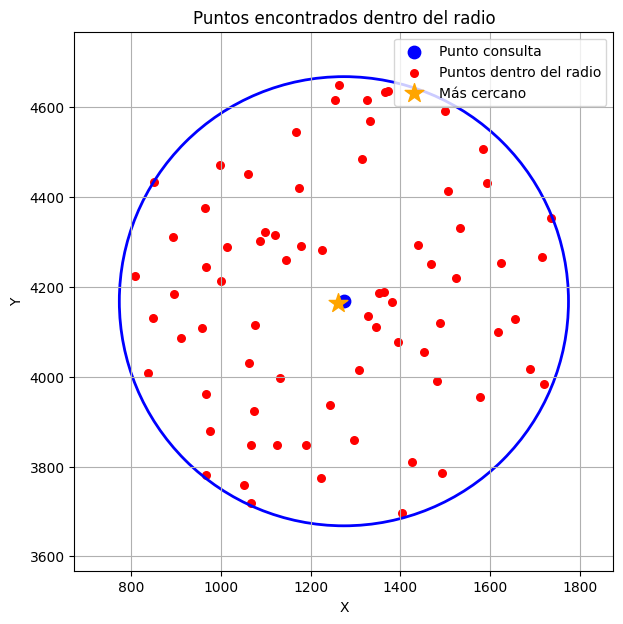

In [16]:
import matplotlib.pyplot as plt

# ----------------------------
# VISUALIZACIÓN SOLO DEL RADIO (Detalle)
# ----------------------------

# Separa las coordenadas X e Y de los puntos encontrados dentro del radio
x_vecinos = [p[0] for p in resultado]
y_vecinos = [p[1] for p in resultado]

# Crea una nueva figura para el gráfico de detalle
plt.figure(figsize=(7, 7))

# Dibuja el punto de consulta en azul
plt.scatter(punto_consulta[0], punto_consulta[1], s=80, color="blue", label="Punto consulta")

# Dibuja los puntos encontrados dentro del radio en rojo
plt.scatter(x_vecinos, y_vecinos, s=30, color="red", label="Puntos dentro del radio")

# Dibuja el vecino más cercano si existe
if resultado:
    plt.scatter(mas_cercano[0], mas_cercano[1],
                color='orange', s=200, marker='*', label="Más cercano")

# Dibuja el círculo que representa el radio de búsqueda
circulo = plt.Circle(punto_consulta, radio, fill=False, color="blue", linewidth=2)
plt.gca().add_patch(circulo)

# Configura los límites de los ejes para mostrar solo la zona del círculo con un margen
margen = 100
plt.xlim(punto_consulta[0] - radio - margen, punto_consulta[0] + radio + margen)
plt.ylim(punto_consulta[1] - radio - margen, punto_consulta[1] + radio + margen)

# Asegura que la relación de aspecto sea igual para un círculo correcto
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Puntos encontrados dentro del radio")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend() # Muestra la leyenda
plt.grid(True) # Muestra una cuadrícula

plt.show() # Muestra el gráfico